# 06g · GSE65391 · RNA_array · pvclust-py on the children's profiles (Python)

Reads `pg_profile_797.csv` and `pg_profile_modules16.csv` (notebook 06d) and `pg_paper_groups.csv`
(notebook 06e). Writes the dendrograms to `figures/GSE65391/`.

**Method** as in notebooks 08c and 08d: pvclust-py (NIH-NLM/pvclust-py, pinned commit 6b0c3bf; Suzuki R,
Shimodaira H. *Bioinformatics* 2006;22:1540–1542), Minkowski p = 2, `ward.D2`, 1,000 bootstrap replicates
per scale, seed 20260928. The children are clustered; the features are resampled.

| profile | features resampled | note |
|---|---|---|
| 797 probes (paper's transcripts) | 797 | probes with an r in every child |
| 16 array modules (ours) | 16 | fewer than 30 units: pvclust-py warns that AU is poorly determined |

The five-network profile has only 5 features and cannot be bootstrapped meaningfully; it is not used here.

**Test.** Which clusters of children reach AU ≥ 0.95 (pvpick)? Are any of them near the size of the paper's
groups (4 to 17 children)?

In [1]:
import warnings
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from scipy.cluster.hierarchy import dendrogram as tree
from pvclust_py.core import pvclust, pvpick

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "endotypes-transcriptomics.yml").exists())
ART  = ROOT / "data" / "run_artifacts" / "GSE65391"
FIG  = ROOT / "figures" / "GSE65391"; FIG.mkdir(parents=True, exist_ok=True)
SEED = 20260928
pd.set_option("display.max_colwidth", None)   # show every cluster member

r797 = pd.read_csv(ART / "pg_profile_797.csv", index_col=0).dropna(axis=1)
m16  = pd.read_csv(ART / "pg_profile_modules16.csv", index_col=0)
g7   = pd.read_csv(ART / "pg_paper_groups.csv").set_index("subject")["group"]
{"r797": r797.shape, "modules16": m16.shape}

{'r797': (83, 713), 'modules16': (83, 16)}

In [2]:
results = {}
for name, P in {"797 probes": r797, "16 modules": m16}.items():
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        results[name] = pvclust(P, cluster="rows", method_dist="minkowski", method_hclust="ward.D2", nboot=1000, seed=SEED)
    for w in caught:
        print(name, "- pvclust-py warning:", w.message)

797 probes - pvclust-py warning: clustering rows means resampling the 713 columns, which are typically correlated rather than independent draws; AU will be anti-conservative (optimistic). Fine for the companion dendrogram of a two-way figure -- just do not quote these p-values as if they were the column ones.


16 modules - pvclust-py warning: clustering rows means resampling the 16 columns, which are typically correlated rather than independent draws; AU will be anti-conservative (optimistic). Fine for the companion dendrogram of a two-way figure -- just do not quote these p-values as if they were the column ones.
16 modules - pvclust-py warning: only 16 resampling units: the multiscale bootstrap has little to work with, and AU will be poorly determined. If these are genes being resampled to assess patient clusters, AU is also anti-conservative.


In [3]:
tables = {}
for name, res in results.items():
    picked = pvpick(res, alpha=0.95)
    tables[name] = pd.DataFrame([{"size": len(e["members"]), "AU": round(e["au"], 3), "BP": round(e["bp"], 3),
                                  "06e groups of members": ", ".join(str(g7[m]) for m in e["members"]),
                                  "members": ", ".join(e["members"])} for e in picked]
                                ).sort_values(["size", "AU"], ascending=False).reset_index(drop=True)
    print(f"{name}: {len(picked)} clusters of children with AU >= 0.95")
tables["797 probes"]

797 probes: 6 clusters of children with AU >= 0.95
16 modules: 11 clusters of children with AU >= 0.95


,size,AU,BP,06e groups of members,members
0,4,0.987,0.922,"2, 2, 2, 2","SLE-128, SLE-210, SLE-271, SLE-321"
1,3,0.960,0.925,"3, 3, 3","SLE-175, SLE-199, SLE-254"
2,2,1.000,1.000,"2, 2","SLE-121, SLE-79"
3,2,0.992,0.969,"3, 3","SLE-245, SLE-339"
4,2,0.976,0.918,"2, 2","SLE-123, SLE-182"
5,2,0.958,0.947,"2, 2","SLE-141, SLE-213"


**Result, 797 probes.** 6 clusters of children reach AU ≥ 0.95: one of 4 children, one of 3 and four of 2
(AU 0.958 to 1.000, BP 0.918 to 1.000). Each lies inside one of the groups of notebook 06e. None is near
the size of the paper's groups (4 to 17), apart from the one of 4, which matches only PG7's size.

In [4]:
tables["16 modules"]

,size,AU,BP,06e groups of members,members
0,5,0.961,0.050,"2, 2, 2, 2, 2","SLE-121, SLE-123, SLE-150, SLE-182, SLE-79"
1,5,0.960,0.025,"3, 1, 6, 1, 1","SLE-172, SLE-183, SLE-189, SLE-55, SLE-99"
2,3,0.997,0.729,"3, 3, 7","SLE-133, SLE-202, SLE-60"
3,3,0.992,0.196,"1, 1, 3","SLE-110, SLE-125, SLE-170"
4,3,0.973,0.049,"4, 4, 1","SLE-163, SLE-20, SLE-225"
5,2,0.999,0.879,"3, 3","SLE-199, SLE-254"
6,2,0.992,0.679,"3, 3","SLE-179, SLE-34"
7,2,0.991,0.586,"1, 2","SLE-65, SLE-80"
8,2,0.988,0.466,"2, 2","SLE-166, SLE-21"
9,2,0.978,0.273,"3, 3","SLE-176, SLE-90"


**Result, 16 modules.** 11 clusters reach AU ≥ 0.95, of 2 to 5 children, most with low BP (0.025 to
0.879). pvclust-py warns that with 16 resampling units AU is poorly determined, and that on this axis it is
anti-conservative.

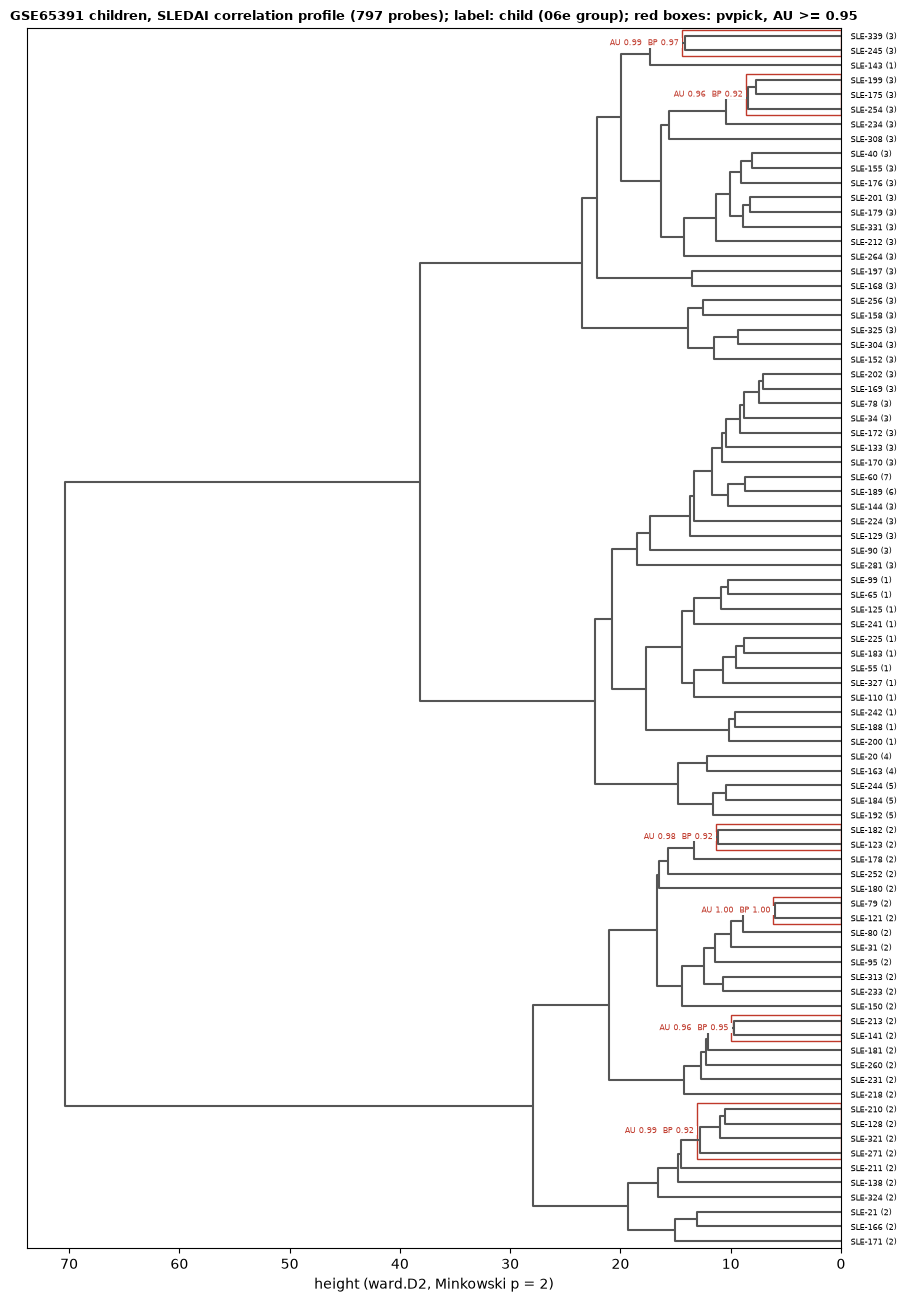

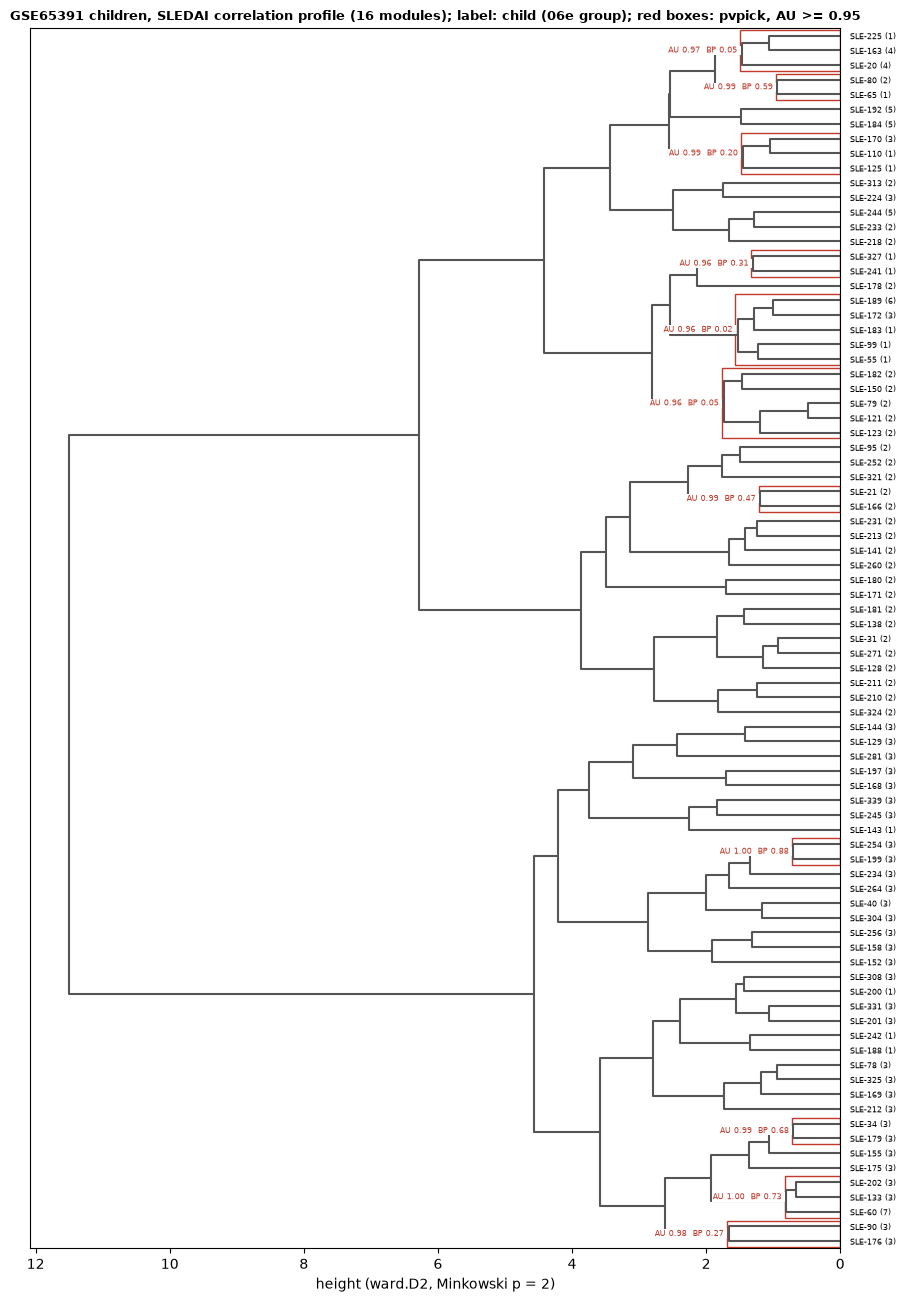

In [5]:
# The pvclust tree with every child labelled. Each red box is one pvpick cluster (AU >= 0.95),
# labelled with its AU and BP values (AU: approximately unbiased; BP: ordinary bootstrap).
def pv_figure(res, picked, title, path):
    n = len(res.labels)
    fig, ax = plt.subplots(figsize=(9, max(4, 0.14 * n + 1.5)))
    d = tree(res.linkage, labels=[f"{l} ({g7[l]})" for l in res.labels], orientation="left", ax=ax,
             color_threshold=0, above_threshold_color="#555555", leaf_font_size=6)
    pos = {res.labels[j]: 5 + 10 * k for k, j in enumerate(d["leaves"])}
    for e in picked:
        ys = [pos[m] for m in e["members"]]
        h = res.linkage[e["merge_order"] - 1, 2] * 1.02
        ax.add_patch(Rectangle((0, min(ys) - 4), h, max(ys) - min(ys) + 8, fill=False, edgecolor="#C0392B", lw=1))
        ax.text(h, (min(ys) + max(ys)) / 2, f"AU {e['au']:.2f}  BP {e['bp']:.2f} ", color="#C0392B",
                fontsize=6, ha="right", va="center",
                bbox=dict(facecolor="white", edgecolor="none", pad=0.3))
    ax.set_xlabel("height (ward.D2, Minkowski p = 2)")
    ax.set_title(title, fontsize=9, fontweight="bold")
    fig.tight_layout()
    fig.savefig(path, dpi=300)
    plt.show()

for name, res in results.items():
    pv_figure(res, pvpick(res, alpha=0.95),
              f"GSE65391 children, SLEDAI correlation profile ({name}); label: child (06e group); red boxes: pvpick, AU >= 0.95",
              FIG / f"06g_PG_pvclust_{name.replace(' ', '_')}.png")

## Summary: claim B6 (seven patient groups)

- **The children.** The paper's 80 are, by their totals, our 83 less three Hispanic children (notebook 06d).
- **The paper's method** (1 − Pearson r on the 797-transcript profile, cut at seven, with average linkage,
  which is our choice because the paper names none) gives groups of 34, 29, 13, 3, 2, 1 and 1, not the
  paper's 17, 16, 13, 11, 10, 9 and 4 (notebook 06e).
- **Our methods find no groups**: the gap statistic gives k = 1 for both profiles (notebook 06f), and
  pvclust supports only clusters of 2 to 5 children (this notebook).
- **Not reproduced.** The children's SLEDAI correlations do combine the paper's five signatures in
  different ways, but they form a continuum, not seven groups.